In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
arr = np.array([6.20, 4.34, 8.14, 6.24, 3.72, 3.54, 4.35, 2.67, 7.16, 6.00])

In [3]:
avg_arr = arr.mean()
std_arr = arr.std()
print(avg_arr)
print(std_arr)
print("Wartosc oczekiwana", np.average(arr))

5.236
1.6734049121476848
Wartosc oczekiwana 5.236


In [4]:
t_stats, p_val = stats.ttest_1samp(arr, popmean=0)

print("T statystyka", t_stats)
print("p value", p_val)

if p_val < 0.05:
    print("Odrzucamy hipoteze zerowa")
else:
    print("Hipoteza zerowa prawdziwa")


T statystyka 9.38684946241732
p value 6.043434137629005e-06
Odrzucamy hipoteze zerowa


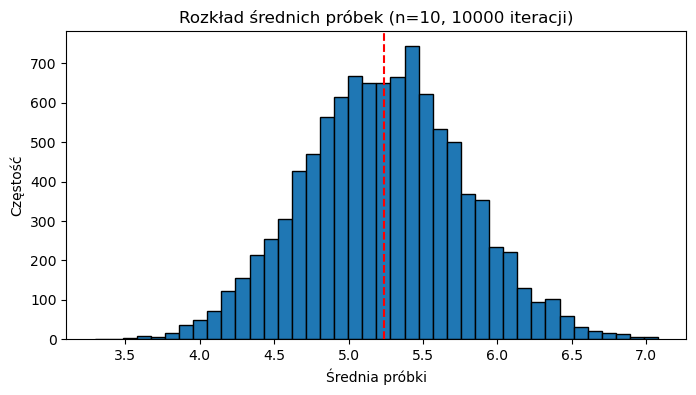

5.237617961896464


In [12]:
size = len(arr)
n_iter = 10000
np.random.seed(42)

sample_means = [np.mean(np.random.normal(loc=avg_arr, scale=std_arr, size=size))
               for i in range(n_iter)]

plt.figure(figsize=(8,4))
plt.hist(sample_means, bins=40, edgecolor='black')
plt.axvline(avg_arr, color='red', linestyle='--', label=f"Średnia danych = {avg_arr:.2f}")
plt.title("Rozkład średnich próbek (n=10, 10000 iteracji)")
plt.xlabel("Średnia próbki")
plt.ylabel("Częstość")
plt.show()

print(np.mean(sample_means))

In [21]:
sorted_sample = np.sort(sample_means)

conf = 0.05
alpha = 1 - conf

trust_range = stats.t.interval(alpha, df=size-1, loc=avg_arr, scale=std_arr/np.sqrt(size))

print(trust_range[0], trust_range[1])

print("95% przedzial ufnosci", lower,":", upper)

4.038918239580342 6.4330817604196575
95% przedzial ufnosci 5.237617961896464 : 5.237617961896464


In [9]:
counter = np.sum(sorted_sample > avg_arr)
n = len(sorted_sample)

ratio = counter / n
print(ratio)

0.5032
